# Data Cleansing

## Import all requirements

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import missingno as msgn
import seaborn as sns
from matplotlib.dates import UTC
from seaborn import move_legend

url = './data/airbnb.csv'
airbnb = pd.read_csv(url)

ModuleNotFoundError: No module named 'missingno'

## Separate the neighbourhood

In [5]:
place = airbnb['neighbourhood_full'].str.partition(',').drop(columns=1)
airbnb['District'] = place[0]
airbnb['Neighborhood'] = place[2]
airbnb = airbnb.drop(columns='neighbourhood_full')

## Price fixing


### Remove dollar sign

In [6]:
airbnb['price'] = airbnb['price'].str.replace('$', '', regex=False)

### Convert prices to numeric values FLOAT

In [7]:
airbnb['price'] = pd.to_numeric(airbnb['price'])
airbnb['price'] = airbnb['price'].fillna(airbnb.groupby(['Neighborhood','District'])['price'].transform('median'))

### Check in case there is a listing with unique placement

In [8]:
airbnb['price'] = airbnb['price'].fillna(airbnb['price'].median())

median = airbnb['price'].median()
airbnb.loc[airbnb['price'] <= 0, 'price'] = median
airbnb['price'].isna().any()

np.False_

### Remove unnecessary Id column and remove any ID duplicates form the dataframe

In [9]:
airbnb = airbnb.drop('Unnamed: 0', axis=1)
airbnb = airbnb.drop_duplicates(subset='listing_id', keep='first')

## Coordinates cleaning

In [10]:
coords = airbnb['coordinates'].str.slice(1, -1).str.partition(',').drop(columns=1)
airbnb['longitude'] = coords[0].astype('float')
airbnb['latitude'] = coords[2].astype('float')
airbnb = airbnb.drop(columns='coordinates')

## Cleaning of the room types

In [11]:
cleanup_rules = {
    'home': 'Entire home/apt',
    'Private': 'Private room',
    'PRIVATE ROOM': 'Private room',
    'Shared room': 'Shared room',
}

airbnb['room_type'] = airbnb['room_type'].str.strip().replace(cleanup_rules)

airbnb['room_type'].unique()

<ArrowStringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str

### Casting listing add data to datetime

In [12]:
airbnb['listing_added'] = pd.to_datetime(airbnb['listing_added'])

airbnb['listing_added'].info()

<class 'pandas.Series'>
Index: 9999 entries, 0 to 10018
Series name: listing_added
Non-Null Count  Dtype         
--------------  -----         
9999 non-null   datetime64[us]
dtypes: datetime64[us](1)
memory usage: 156.2 KB


## Mark not visited places

In [13]:
airbnb['last_review'] = pd.to_datetime(airbnb['last_review'])

airbnb['visited'] = ~airbnb['last_review'].isna()

## Replace reviews per month with 0 if there are no reviews

In [14]:
airbnb['reviews_per_month'] = airbnb['reviews_per_month'].fillna(airbnb['number_of_reviews'])

## Check availability and review's correctness

In [15]:
airbnb.loc[airbnb['availability_365'] > 365, ['availability_365']] = 365

airbnb = airbnb[airbnb['availability_365'] <= 365]

### Check in case of wrongly calculated 5 start rating

In [16]:
airbnb.loc[airbnb['5_stars'] > 5.0, ['5_stars']] = 5.0

## Fill the *Nan* house names with *House*

In [17]:
airbnb['name'] = airbnb['name'].fillna('House')

## Drop the airbnbs without owners

In [18]:
airbnb = airbnb.dropna(subset=['host_name'])

## Check if its okay

listing_id              0
name                    0
host_id                 0
host_name               0
room_type               0
price                   0
number_of_reviews       0
last_review          2070
reviews_per_month       0
availability_365        0
rating               2070
number_of_stays      2070
5_stars              2070
listing_added           0
District                0
Neighborhood            0
longitude               0
latitude                0
visited                 0
dtype: int64


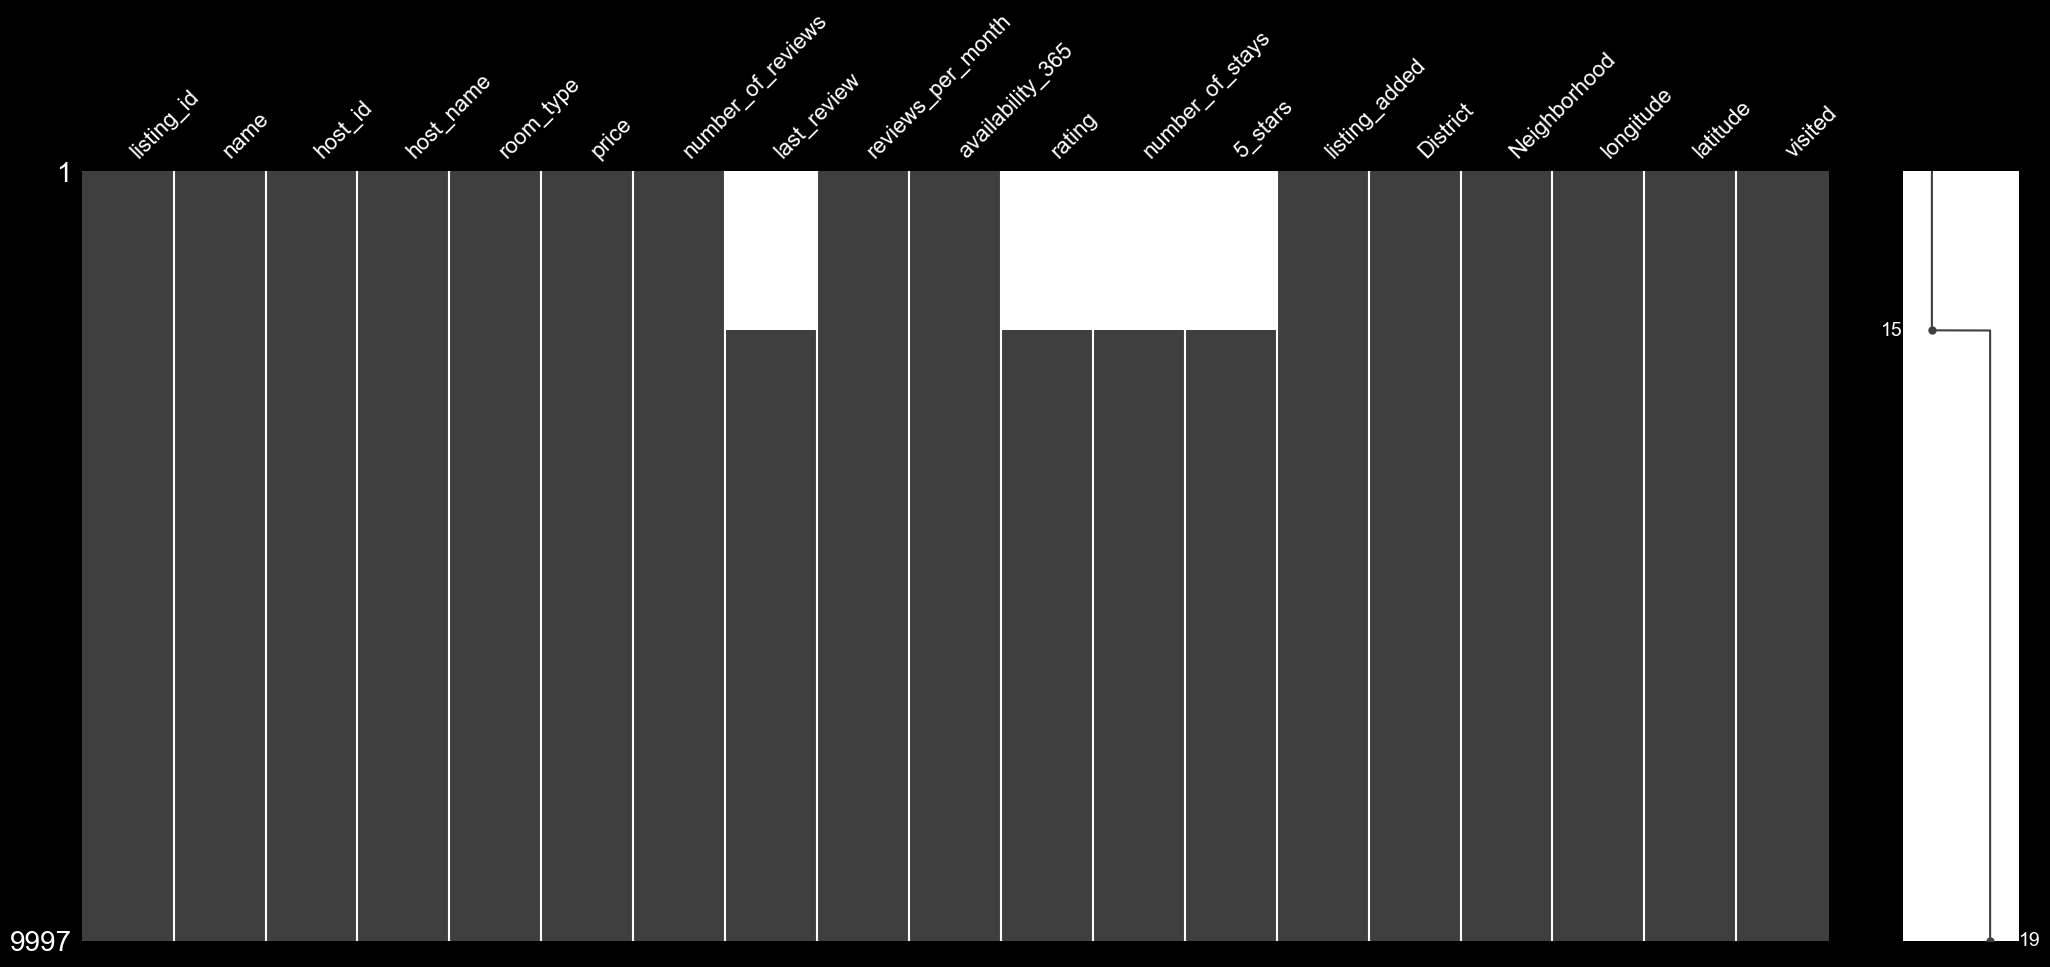

In [19]:
msgn.matrix(airbnb, sort='ascending')
print(airbnb.isna().sum())

All missing review's columns are connected therefore it's probably caused by place simply not being visited / rated.

In [20]:
airbnb

,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,rating,number_of_stays,5_stars,listing_added,District,Neighborhood,longitude,latitude,visited
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,Private room,45.0,10,2018-12-12,0.70,85,4.100954,12.0,0.609432,2018-06-08,Brooklyn,Flatlands,40.63222,-73.93398,True
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,Entire home/apt,135.0,1,2019-06-30,1.00,145,3.367600,1.2,0.746135,2018-12-25,Manhattan,Upper West Side,40.78761,-73.96862,True
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,Entire home/apt,150.0,0,NaT,0.00,65,NaN,NaN,NaN,2018-08-15,Brooklyn,Brooklyn Heights,40.70070,-73.99517,False
3,6425850,"Spacious, charming studio",32715865,Yelena,Entire home/apt,86.0,5,2017-09-23,0.13,0,4.763203,6.0,0.769947,2017-03-20,Manhattan,Upper West Side,40.79169,-73.97498,True
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,Private room,160.0,23,2019-06-12,2.29,102,3.822591,27.6,0.649383,2020-10-23,Manhattan,Lower East Side,40.71884,-73.98354,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10014,22307861,Lovely 1BR Harlem apartment,16004068,Rachel,Entire home/apt,105.0,4,2018-05-28,0.21,0,4.757555,4.8,0.639223,2017-11-22,Manhattan,Harlem,40.80379,-73.95257,True
10015,953275,Apartment For Your Holidays in NYC!,4460034,Alain,Entire home/apt,125.0,50,2018-05-06,0.66,188,4.344704,60.0,0.648778,2017-10-31,Manhattan,East Harlem,40.79531,-73.93330,True
10016,3452835,"Artsy, Garden Getaway in Central Brooklyn",666862,Amy,Entire home/apt,100.0,45,2016-11-27,0.98,0,3.966214,54.0,0.631713,2016-05-24,Brooklyn,Clinton Hill,40.68266,-73.96743,True
10017,23540194,"Immaculate townhouse in Clinton Hill, Brooklyn",67176930,Sophie,Entire home/apt,450.0,2,2019-05-31,0.17,99,4.078581,2.4,0.703360,2018-11-25,Brooklyn,Clinton Hill,40.68832,-73.96366,True


## Visualize using seaborn

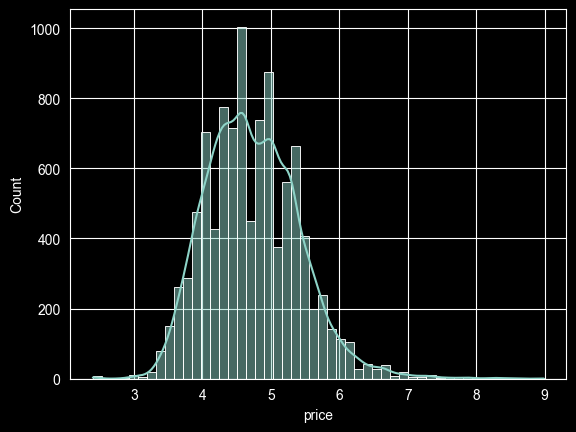

In [21]:
log_price = np.log1p(airbnb['price'])

sns.histplot(log_price, kde=True,bins=50)

airbnb['price_log'] = log_price

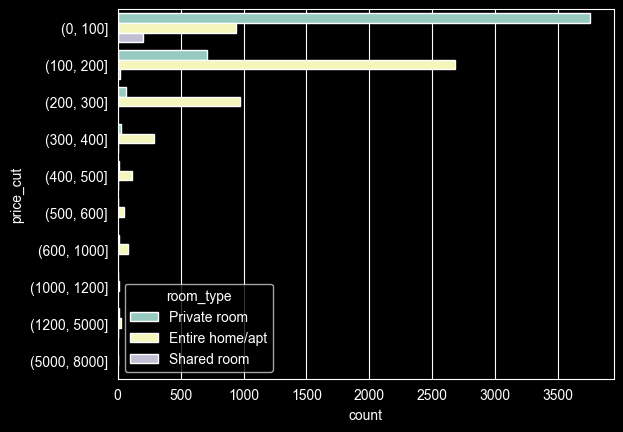

In [22]:
airbnb['price_cut']= pd.cut(airbnb['price'], [0, 100 , 200, 300, 400, 500, 600, 1000, 1200, 5000, 8000])

# airbnb['price_cut'] = airbnb['price_cut'].value_counts()
# airbnb
sns.countplot(data=airbnb, y='price_cut', hue='room_type');

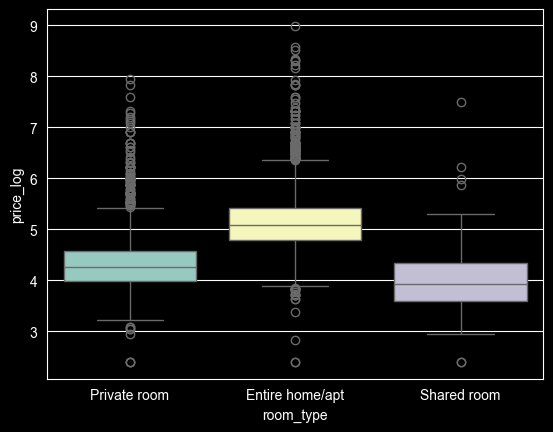

In [23]:
sns.boxplot(data=airbnb, x='room_type', y='price_log', hue='room_type', legend=False);

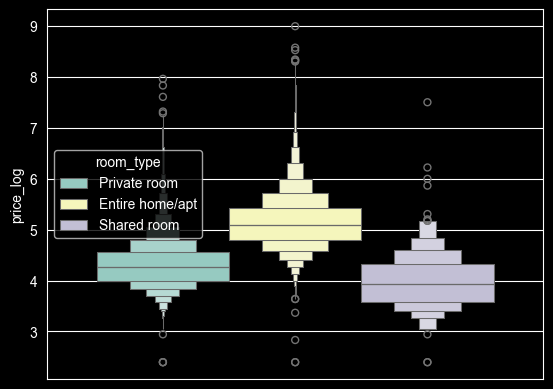

In [24]:
sns.boxenplot(airbnb, y='price_log', hue='room_type');

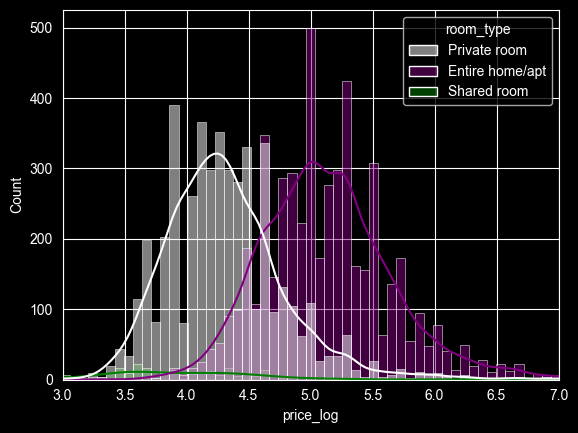

In [25]:
sns.histplot(airbnb, x='price_log', hue='room_type', kde=True, alpha=0.5, bins=90,
                palette={'Private room': 'white', 'Entire home/apt': 'purple', 'Shared room': 'green'}
             )
plt.xlim(3,7);

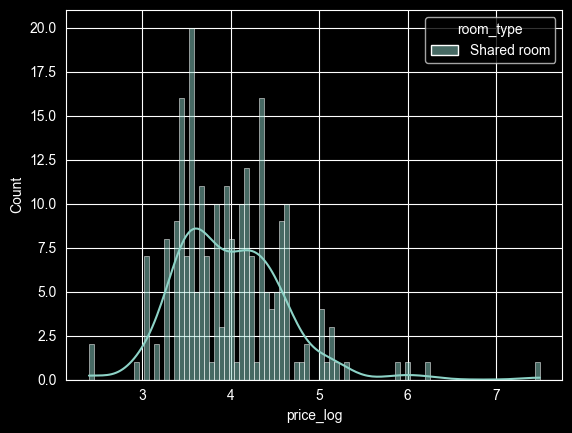

In [26]:
sns.histplot(airbnb[airbnb['room_type'] == 'Shared room'], x='price_log', kde=True, alpha=0.5, bins=90, hue='room_type');

In [27]:
whole_dsc = airbnb.drop(['listing_id', 'host_id'], axis=1).groupby(airbnb['room_type']).describe()

price_dsc = airbnb['price'].groupby(airbnb['room_type']).describe()

price_dsc

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,5173.0,207.885946,249.546188,10.0,120.0,160.0,225.0,8000.0
Private room,4598.0,87.956068,101.704013,10.0,53.0,70.0,95.0,2850.0
Shared room,226.0,71.126106,127.409692,10.0,35.0,50.0,75.0,1800.0


In [28]:
from skimpy import skim

print(skim(airbnb.drop(['listing_id','host_id', 'room_type', 'host_name', 'longitude', 'latitude'], axis=1)))
airbnb

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 9997   │ │ float64     │ 6     │ │ price_cut             │                                │
│ │ Number of columns │ 15     │ │ string      │ 3     │ └───────────────────────┘                                │
│ └───────────────────┴────────┘ │ int64       │ 2     │                                                          │
│                                │ datetime64  │ 2     │                                                          │
│                                │ bool        │ 1     │                                                          │
│                                │ category    │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column        ┃ NA   ┃ NA %         ┃ mean   ┃ sd      ┃ p0    ┃ p25    ┃ p50    ┃ p75   ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │     price     │    0 │            0 │  149.6 │   202.5 │    10 │     69 │    105 │   177 │   8000 │   █    │  │
│ │ number_of_rev │    0 │            0 │  22.47 │   43.19 │     0 │      1 │      5 │    22 │    510 │   █    │  │
│ │     iews      │      │              │        │         │       │        │        │       │        │        │  │
│ │ reviews_per_m │    0 │            0 │  1.074 │   1.541 │     0 │   0.04 │   0.37 │  1.55 │  16.22 │   █▁   │  │
│ │     onth      │      │              │        │         │       │        │        │       │        │        │  │
│ │ availability_ │    0 │            0 │  112.3 │   131.6 │     0 │      0 │     44 │   226 │    365 │ █▂▁▁▁▂ │  │
│ │      365      │      │              │        │         │       │        │        │       │        │        │  │
│ │    rating     │ 2070 │ 20.706211863 │  4.014 │   0.575 │ 3.001 │   3.52 │  4.029 │ 4.516 │  5.181 │ ▇█▇██▄ │  │
│ │               │      │        55907 │        │         │       │        │        │       │        │        │  │
│ │ number_of_sta │ 2070 │ 20.706211863 │  34.01 │   56.11 │   1.2 │    3.6 │   10.8 │  38.4 │    612 │   █▁   │  │
│ │      ys       │      │        55907 │        │         │       │        │        │       │        │        │  │
│ │    5_stars    │ 2070 │ 20.706211863 │ 0.7186 │ 0.07997 │   0.6 │ 0.6556 │ 0.7097 │ 0.764 │ 0.9503 │ ███▃▂▁ │  │
│ │               │      │        55907 │        │         │       │        │        │       │        │        │  │
│ │   price_log   │    0 │            0 │  4.735 │  0.6802 │ 2.398 │  4.248 │  4.663 │ 5.182 │  8.987 │   ▇█▁  │  │
│ └───────────────┴──────┴──────────────┴────────┴─────────┴───────┴────────┴────────┴───────┴────────┴────────┘  │
│                                                    category                                                     │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column                        ┃ NA        ┃ NA %            ┃ ordered                ┃ unique              ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━

None


,listing_id,name,host_id,host_name,room_type,price,number_of_reviews,last_review,reviews_per_month,availability_365,...,number_of_stays,5_stars,listing_added,District,Neighborhood,longitude,latitude,visited,price_log,price_cut
0,13740704,"Cozy,budget friendly, cable inc, private entra...",20583125,Michel,Private room,45.0,10,2018-12-12,0.70,85,...,12.0,0.609432,2018-06-08,Brooklyn,Flatlands,40.63222,-73.93398,True,3.828641,"(0, 100]"
1,22005115,Two floor apartment near Central Park,82746113,Cecilia,Entire home/apt,135.0,1,2019-06-30,1.00,145,...,1.2,0.746135,2018-12-25,Manhattan,Upper West Side,40.78761,-73.96862,True,4.912655,"(100, 200]"
2,21667615,Beautiful 1BR in Brooklyn Heights,78251,Leslie,Entire home/apt,150.0,0,NaT,0.00,65,...,NaN,NaN,2018-08-15,Brooklyn,Brooklyn Heights,40.70070,-73.99517,False,5.017280,"(100, 200]"
3,6425850,"Spacious, charming studio",32715865,Yelena,Entire home/apt,86.0,5,2017-09-23,0.13,0,...,6.0,0.769947,2017-03-20,Manhattan,Upper West Side,40.79169,-73.97498,True,4.465908,"(0, 100]"
4,22986519,Bedroom on the lively Lower East Side,154262349,Brooke,Private room,160.0,23,2019-06-12,2.29,102,...,27.6,0.649383,2020-10-23,Manhattan,Lower East Side,40.71884,-73.98354,True,5.081404,"(100, 200]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10014,22307861,Lovely 1BR Harlem apartment,16004068,Rachel,Entire home/apt,105.0,4,2018-05-28,0.21,0,...,4.8,0.639223,2017-11-22,Manhattan,Harlem,40.80379,-73.95257,True,4.663439,"(100, 200]"
10015,953275,Apartment For Your Holidays in NYC!,4460034,Alain,Entire home/apt,125.0,50,2018-05-06,0.66,188,...,60.0,0.648778,2017-10-31,Manhattan,East Harlem,40.79531,-73.93330,True,4.836282,"(100, 200]"
10016,3452835,"Artsy, Garden Getaway in Central Brooklyn",666862,Amy,Entire home/apt,100.0,45,2016-11-27,0.98,0,...,54.0,0.631713,2016-05-24,Brooklyn,Clinton Hill,40.68266,-73.96743,True,4.615121,"(0, 100]"
10017,23540194,"Immaculate townhouse in Clinton Hill, Brooklyn",67176930,Sophie,Entire home/apt,450.0,2,2019-05-31,0.17,99,...,2.4,0.703360,2018-11-25,Brooklyn,Clinton Hill,40.68832,-73.96366,True,6.111467,"(400, 500]"


# HEATMAP

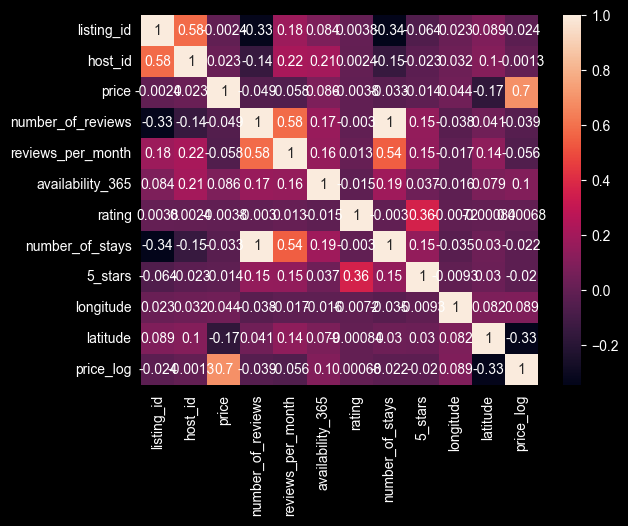

In [29]:
heat = airbnb.select_dtypes(include='number').corr()
sns.heatmap(heat , annot=True)
plt.show()

# Map of US thanks for scatterplot. (displayed coordinates)

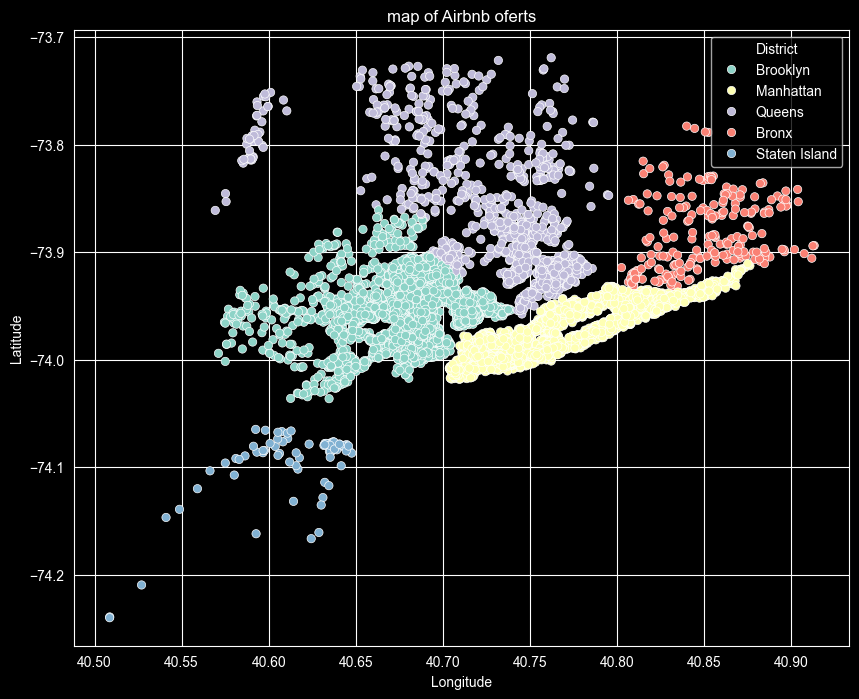

In [30]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=airbnb,
    x=airbnb['longitude'],
    y=airbnb['latitude'],
    hue='District'
)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.title('map of Airbnb oferts')
plt.show()

Na tej mapce widac rozłożenie obiektów na wynajem na mapie Nowego Jorku oraz ich podział na dzielnice i ich zagęszczenie w poszczególnych dzielnicach

Text(0, 0.5, 'AVG price')

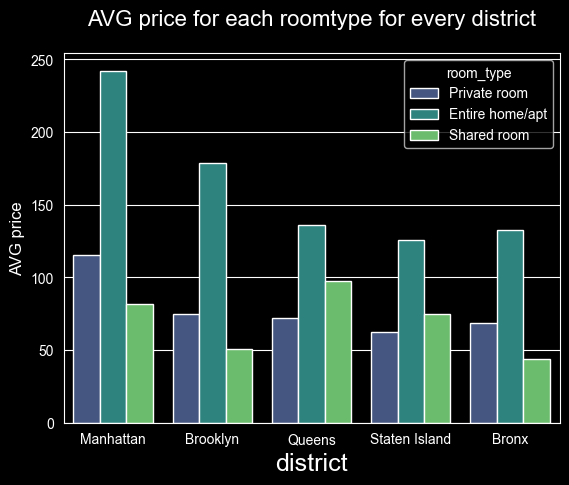

In [42]:
district_price = airbnb.groupby('District')['price'].mean().sort_values(ascending=False).index

ax = sns.barplot(
    data=airbnb,
    x='District',
    y='price',
    order=district_price,
    palette='viridis',
    hue='room_type',
    errorbar=None
)
plt.title('AVG price for each roomtype for every district', fontsize=16, pad=20)
plt.xlabel('district', fontsize=18)
plt.ylabel('AVG price', fontsize=12)


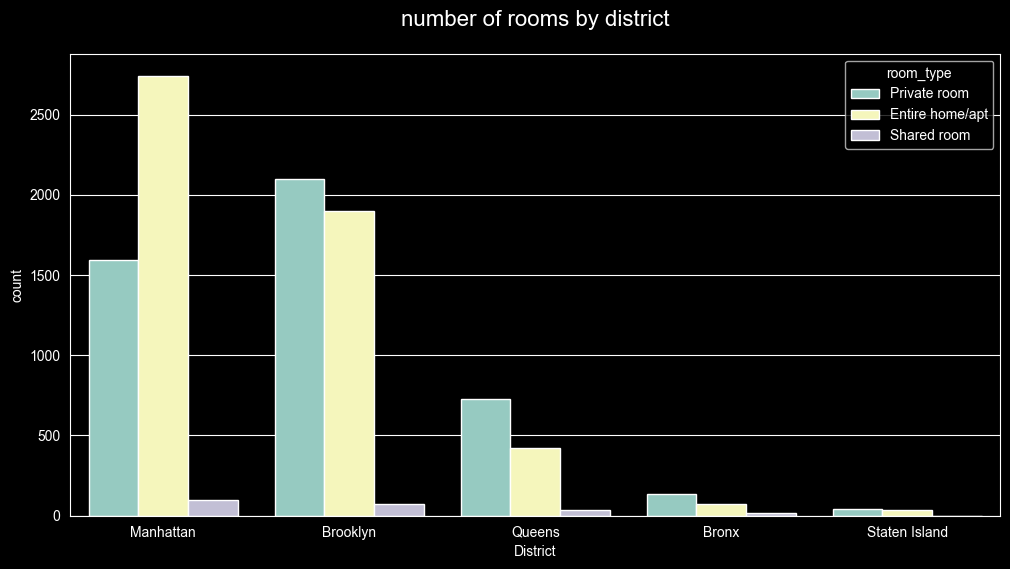

In [41]:
plt.figure(figsize=(12, 6))

district_order = airbnb['District'].value_counts().index

sns.countplot(
    data=airbnb,
    x='District',
    hue='room_type',
    order=district_order
)

plt.title('number of rooms by district', fontsize=16, pad=20)
plt.show()

In [5]:
from scipy.stats import skew, kurtosis
from tabulate import tabulate
grouped_hotels = airbnb.groupby('room_type')['price']
grouped_summary = grouped_hotels.describe().T

grouped_summary.loc['skewness'] = grouped_hotels.apply(skew)
grouped_summary.loc['kurtosis'] = grouped_hotels.apply(kurtosis)

print(tabulate(grouped_summary, headers='keys', tablefmt='grid'))




NameError: name 'airbnb' is not defined